In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### data loading and preprocessing

##### feature selection

In [15]:
df = pd.read_csv('age_gender.csv')
data = df.drop(['ethnicity','age','img_name'], axis=1)
print(data.shape)
data.head()

(23705, 2)


,gender,pixels
0,0,129 128 128 126 127 130 133 135 139 142 145 14...
1,0,164 74 111 168 169 171 175 182 184 188 193 199...
2,0,67 70 71 70 69 67 70 79 90 103 116 132 145 155...
3,0,193 197 198 200 199 200 202 203 204 205 208 21...
4,0,202 205 209 210 209 209 210 211 212 214 218 21...


In [3]:

data.isnull().sum()

gender    0
pixels    0
dtype: int64

#### data visualisation 

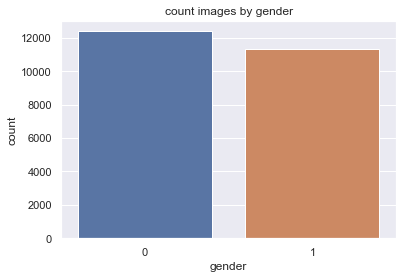

In [4]:
sns.set()
sns.countplot(data['gender'])
plt.title('count images by gender')
plt.show()

In [16]:
def pixels_to_array(pixels):
    array = pixels.split(' ')
    array = np.array(array, dtype='uint8')
    array = array.reshape(48,48,1)
    return array

In [17]:
data['pixels'] = data['pixels'].apply(pixels_to_array)
data.head()

,gender,pixels
0,0,"[[[129], [128], [128], [126], [127], [130], [1..."
1,0,"[[[164], [74], [111], [168], [169], [171], [17..."
2,0,"[[[67], [70], [71], [70], [69], [67], [70], [7..."
3,0,"[[[193], [197], [198], [200], [199], [200], [2..."
4,0,"[[[202], [205], [209], [210], [209], [209], [2..."


In [7]:
data['pixels'].shape

(23705,)

In [8]:
data['pixels'][0].shape

(48, 48, 1)

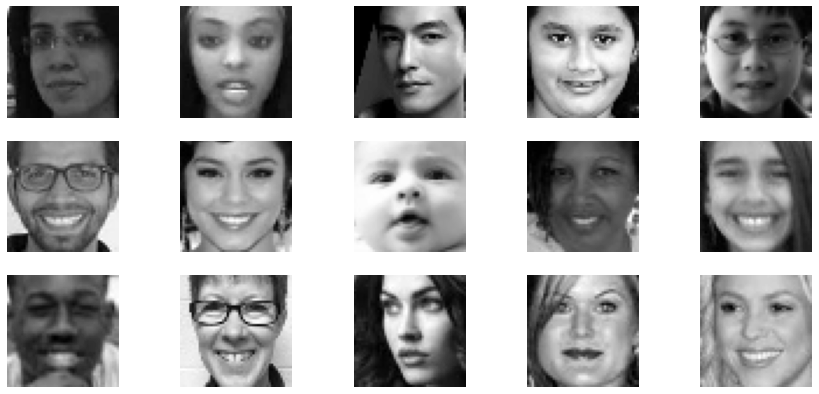

In [10]:
plt.figure(figsize=(15,7))
for i in range(15):
    plt.subplot(3,5,i+1)
    img = data['pixels'][np.random.randint(0,20000)].reshape(48,48)
    plt.imshow(img, cmap='gray')
    plt.axis('off')

### data preperocessing and model building 

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import itertools
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical # convert to one-hot-encoding
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D, BatchNormalization, InputLayer
from tensorflow.keras.optimizers import RMSprop,Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.losses import BinaryCrossentropy, SparseCategoricalCrossentropy

In [19]:
data[['pixels']].values.shape

(23705, 1)

In [20]:
X = data['pixels'].values
X = np.stack(np.array(X), axis=0)
X = X.reshape(-1, 48,48,1)
X = X/255.0
print(X.shape)

Y = data[['gender']].values
Y = tf.keras.utils.to_categorical(Y, num_classes=2)
print(Y.shape)

(23705, 48, 48, 1)
(23705, 2)


#### data spliting 

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)
X_train.shape

(18964, 48, 48, 1)

#### model build 

In [10]:
model = Sequential()
model.add(Conv2D(16, kernel_size=(3, 3), activation='relu', padding = "same", input_shape=(48,48,1)))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.2))
model.add(Conv2D(32, kernel_size=(3,3),activation="relu",padding="same"))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.2))
model.add(Conv2D(64, kernel_size=(3,3),activation="relu",padding="same"))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.2))
model.add(Flatten())
model.add(Dense(256,activation="relu"))
model.add(Dense(2, activation="sigmoid"))

model.compile(optimizer='Adam',
          loss= 'categorical_crossentropy',
          metrics=['accuracy'])

In [14]:
epochs = 20  
history = model.fit(X_train, y_train, batch_size=64,
                              epochs = epochs, validation_data = (X_test,y_test))

Epoch 1/20
297/297 [==============================] - 42s 140ms/step - loss: 0.1933 - accuracy: 0.9177 - val_loss: 0.2580 - val_accuracy: 0.9021
Epoch 2/20
297/297 [==============================] - 44s 150ms/step - loss: 0.1786 - accuracy: 0.9258 - val_loss: 0.2739 - val_accuracy: 0.8952
Epoch 3/20
297/297 [==============================] - 44s 147ms/step - loss: 0.1718 - accuracy: 0.9285 - val_loss: 0.2657 - val_accuracy: 0.8977
Epoch 4/20
297/297 [==============================] - 43s 144ms/step - loss: 0.1575 - accuracy: 0.9351 - val_loss: 0.2679 - val_accuracy: 0.8935
Epoch 5/20
297/297 [==============================] - 43s 146ms/step - loss: 0.1529 - accuracy: 0.9396 - val_loss: 0.3108 - val_accuracy: 0.8779
Epoch 6/20
297/297 [==============================] - 43s 145ms/step - loss: 0.1409 - accuracy: 0.9422 - val_loss: 0.2840 - val_accuracy: 0.8941
Epoch 7/20
297/297 [==============================] - 45s 153ms/step - loss: 0.1389 - accuracy: 0.9429 - val_loss: 0.2765 - val_ac

In [15]:
model.save('gender_model.h5')

### rerun the model 

In [35]:
from sklearn.metrics import confusion_matrix, classification_report,ConfusionMatrixDisplay
from tensorflow.keras.models import load_model

In [12]:


model=load_model('gender_model.h5')

In [22]:
training_score=model.evaluate(X_train,y_train)
test_score=model.evaluate(X_test,y_test)

149/149 [==============================] - 3s 17ms/step - loss: 0.1273 - accuracy: 0.9597


In [29]:
y_test[:5]

array([[0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.]], dtype=float32)

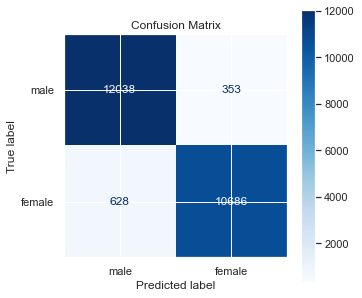

In [38]:
y_true= data[['gender']].values
y_pred=model.predict(X)
y_pred=np.argmax(y_pred,axis=1)
cm=confusion_matrix(y_true,y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['male','female'])
fig, ax =plt.subplots(figsize=(5,5))
plt.title('Confusion Matrix')
disp.plot(cmap='Blues',ax=ax)
plt.show()

In [39]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96     12391
           1       0.97      0.94      0.96     11314

    accuracy                           0.96     23705
   macro avg       0.96      0.96      0.96     23705
weighted avg       0.96      0.96      0.96     23705

